# Tutorial: decomposing the ECCO V4r4 heat budget

This companion to `eccov4r4_budget_examples_mass_heat_salt.ipynb` shows how to **decompose** the native-grid (LLC90) ECCO heat budget into its physical contributions (advection, diffusion, surface forcing, …) with `xbudget`, mirroring the decomposition workflow in `MOM6_budget_examples_mass_heat_salt.ipynb`.

In [1]:
import xarray as xr
import numpy as np
from scipy.interpolate import griddata
import xgcm
import matplotlib.pyplot as plt
import xbudget

from load_example_ecco_grid import * 
from eccov4r4_budget_diagnostics import * 
print("xarray:",  xr.__version__)
print("xgcm:", xgcm.__version__)

xarray: 2025.7.1
xgcm: 0.10.0


### Load the example ECCO V4r4 grid

In [2]:
grid = load_ECCOV4r4_budget_diagnostics()  # first run downloads ~2.6 GB from Zenodo, then cached in ../data

# Build a time-step coordinate and a cell-volume metric used repeatedly below.
dt = grid._ds["time_bounds"].diff("time_bounds").rename({"time_bounds":"time"})

grid._ds = grid._ds.assign_coords(
    {"dt":("time", dt.dt.total_seconds().values), 
    "volcello": (grid._ds["drF"] * grid._ds["hFacC"]) * grid._ds["rA"]
    }
)

File 'GRID_GEOMETRY_ECCO_V4r4_native_llc0090.nc' already exists at ../data/GRID_GEOMETRY_ECCO_V4r4_native_llc0090.nc. Skipping download.


File 'OCEAN_TEMPERATURE_SALINITY_mon_mean_2010_ECCO_V4r4_native_llc0090.nc' already exists at ../data/OCEAN_TEMPERATURE_SALINITY_mon_mean_2010_ECCO_V4r4_native_llc0090.nc. Skipping download.
File 'OCEAN_3D_VOLUME_FLUX_mon_mean_2010_ECCO_V4r4_native_llc0090.nc' already exists at ../data/OCEAN_3D_VOLUME_FLUX_mon_mean_2010_ECCO_V4r4_native_llc0090.nc. Skipping download.
File 'OCEAN_3D_TEMPERATURE_FLUX_mon_mean_2010_ECCO_V4r4_native_llc0090.nc' already exists at ../data/OCEAN_3D_TEMPERATURE_FLUX_mon_mean_2010_ECCO_V4r4_native_llc0090.nc. Skipping download.
File 'OCEAN_3D_SALINITY_FLUX_mon_mean_2010_ECCO_V4r4_native_llc0090.nc' already exists at ../data/OCEAN_3D_SALINITY_FLUX_mon_mean_2010_ECCO_V4r4_native_llc0090.nc. Skipping download.
File 'OCEAN_AND_ICE_SURFACE_HEAT_FLUX_mon_mean_2010_ECCO_V4r4_native_llc0090.nc' already exists at ../data/OCEAN_AND_ICE_SURFACE_HEAT_FLUX_mon_mean_2010_ECCO_V4r4_native_llc0090.nc. Skipping download.
File 'OCEAN_AND_ICE_SURFACE_FW_FLUX_mon_mean_2010_ECCO_V4

### Preprocess the ECCO diagnostics into xbudget's budget components

In [3]:
def zero_top_layer(ds, varname = "", zdim = "k_l"):
    # Remove the surface layer contribution when a diagnostic should only represent interior transport.
    return xr.where(ds[f"{zdim}"] != ds[f"{zdim}"].isel({f"{zdim}":0}),ds[varname].copy(),0.0,)
def make_flux_3d(ds, varname = "", zdim = "k"):
    # Broadcast a surface flux into a 3D array that only occupies the top model layer.
    k  = ds[f"{zdim}"]
    return xr.where(k == k.isel({f"{zdim}":0}), ds[varname].copy().expand_dims({f"{zdim}":k}),0.0,)

# Assemble ECCO heat-flux terms into the budget components expected by xbudget.
grid._ds["geothermal_heat_flux_convergence"] = eccov4r4_geothermal_heat_flux_tendency(grid._ds) 
grid._ds["pen_boundary_forcing_heat_tendency"] = eccov4r4_penetrative_heat_flux_tendency(grid._ds)
grid._ds["nonpen_boundary_forcing_heat_tendency"] = eccov4r4_nonpenetrative_heat_flux_tendency(grid._ds)
grid._ds["boundary_forcing_heat_tendency"] = grid._ds["pen_boundary_forcing_heat_tendency"] + grid._ds["nonpen_boundary_forcing_heat_tendency"]

# Put the sea-ice salt exchange and salt-plume tendency onto the same vertical grid.
SFLUX = grid._ds["SFLUX"].assign_coords(k=0).expand_dims(dim='k',axis=1) # sea-ice salt exchange
grid._ds["boundary_forcing_salt_tendency"] = xr.concat([SFLUX+grid._ds["oceSPtnd"],grid._ds["oceSPtnd"].isel(k=slice(1,None))], dim='k') # combine surface salt flux and plume tendency

# Separate interior vertical transport from the freshwater boundary forcing term.
grid._ds["WVELMASS_interior"] = zero_top_layer(grid._ds, varname = "WVELMASS", zdim = "k_l") #
grid._ds["boundary_forcing_volume_tendency"] = make_flux_3d(grid._ds, varname = "oceFWflx", zdim = "k")

# GM eddy-bolus mass transports (kg/s) for downstream water-mass transformation (xwmb).
# The bolus is excluded from the (Eulerian) volume budget -- it is non-divergent and
# carries zero net volume -- but its transport across isopycnals is a real transformation
# term. Named to match the `bolus` metadata block in ECCOV4r4_native.yaml.
rho0 = 1029.0
grid._ds["bolus_x_mass_transport"] = rho0 * grid._ds["UVELSTAR"] * grid._ds["dyG"] * grid._ds["drF"]
grid._ds["bolus_y_mass_transport"] = rho0 * grid._ds["VVELSTAR"] * grid._ds["dxG"] * grid._ds["drF"]
grid._ds["bolus_z_mass_transport"] = rho0 * grid._ds["WVELSTAR"] * grid._ds["rA"]

# Rechunk once before calling xbudget so later difference and convergence steps stay tractable.
grid._ds = grid._ds.chunk({"tile":2, "i":50, "j":50, "i_g":50, "j_g":50, "k": 10}).fillna(0.0)
# to-do: add comparable chunking inside the difference and convergence routines 

### Collect the budget terms

`collect_budgets` computes every term and writes it into the dataset; `BudgetQuery` is how we look them up afterwards.

In [4]:
recipe = xbudget.load_preset_budget(model="ECCOV4r4_native").copy()
xbudget.collect_budgets(grid, recipe, allow_rechunk=True)
q = xbudget.BudgetQuery(grid, recipe)

/Users/henrifdrake/code/xbudget/.claude/worktrees/ecco-data/xbudget/evaluate.py:375: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn(


/Users/henrifdrake/code/xbudget/.claude/worktrees/ecco-data/xbudget/evaluate.py:375: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn(


/Users/henrifdrake/code/xbudget/.claude/worktrees/ecco-data/xbudget/evaluate.py:375: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn(


/Users/henrifdrake/code/xbudget/.claude/worktrees/ecco-data/xbudget/evaluate.py:375: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn(


/Users/henrifdrake/code/xbudget/.claude/worktrees/ecco-data/xbudget/evaluate.py:375: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn(


...

/Users/henrifdrake/code/xbudget/.claude/worktrees/ecco-data/xbudget/collect.py:40: UserWarning: Summing terms with mismatched dimensions while building 'heat_rhs': the operands carry dimension sets [('i', 'j', 'k', 'tile', 'time'), ('i', 'j', 'k', 'tile', 'time'), ('i', 'j', 'k', 'tile', 'time'), ('i', 'j', 'k', 'tile')]. xarray will broadcast the lower-dimensional term(s) across ('time',), e.g. spreading a 2D surface flux uniformly over the vertical of a 3D flux convergence instead of depositing it at the outcropping level. Verify this broadcast is intended; see https://github.com/hdrake/xbudget/issues/11.
  warnings.warn(


/Users/henrifdrake/code/xbudget/.claude/worktrees/ecco-data/xbudget/evaluate.py:375: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn(


/Users/henrifdrake/code/xbudget/.claude/worktrees/ecco-data/xbudget/evaluate.py:375: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn(


/Users/henrifdrake/code/xbudget/.claude/worktrees/ecco-data/xbudget/evaluate.py:375: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn(


/Users/henrifdrake/code/xbudget/.claude/worktrees/ecco-data/xbudget/evaluate.py:375: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn(


### Decompose the heat budget

`aggregate` collapses the budget tree into a flat mapping of high-level terms to variable names. Passing `decompose=[...]` breaks the named terms into their constituent parts — here we split the right-hand-side heat sources/sinks into advection, diffusion, and surface-exchange-flux components.

In [5]:
decomposed = q.aggregate(
    decompose=["advection", "diffusion", "surface_exchange_flux"]
)
heat_rhs_terms = decomposed["heat"]["rhs"]
heat_rhs_terms

{'advection_lateral': 'heat_rhs_advection_lateral',
 'advection_interfacial': 'heat_rhs_advection_interfacial',
 'diffusion_lateral': 'heat_rhs_diffusion_lateral',
 'diffusion_explicit_vertical_diffusion': 'heat_rhs_diffusion_explicit_vertical_diffusion',
 'diffusion_implicit_vertical_diffusion': 'heat_rhs_diffusion_implicit_vertical_diffusion',
 'surface_exchange_flux': 'heat_rhs_surface_exchange_flux',
 'bottom_flux': 'heat_rhs_bottom_flux'}

### Plot the decomposed heat-budget terms

Each term is a native volume-integrated heat tendency (J/s); we convert to a column tendency per unit area (W/m²) and remap the LLC tiles to lat-lon for visualization.

In [6]:
def plot_interpolated_ecco(fig, ax, ds, vmin=0, vmax=30, cmap="coolwarm"):
    # Build a simple regular lat-lon target grid for quick visual comparison.
    target_lon = np.arange(-180, 180, 1)
    target_lat = np.arange(-90, 90, 1)
    lon_grid, lat_grid = np.meshgrid(target_lon, target_lat)
    
    # Flatten the LLC field into point/value pairs for interpolation.
    points = np.column_stack((ds.XC.values.ravel(), ds.YC.values.ravel()))
    values = ds.values.ravel()
    
    # Use nearest-neighbor remapping to preserve the native diagnostic values.
    interpolated_data = griddata(points, values, (lon_grid, lat_grid), method='nearest')
    
    # Plot the remapped field.
    cb = ax.pcolormesh(lon_grid, lat_grid, interpolated_data, 
                       vmin=vmin, vmax=vmax, cmap=cmap)
    
    return cb

Text(0.5, 0.98, 'ECCO heat budget RHS, decomposed (column tendency)')

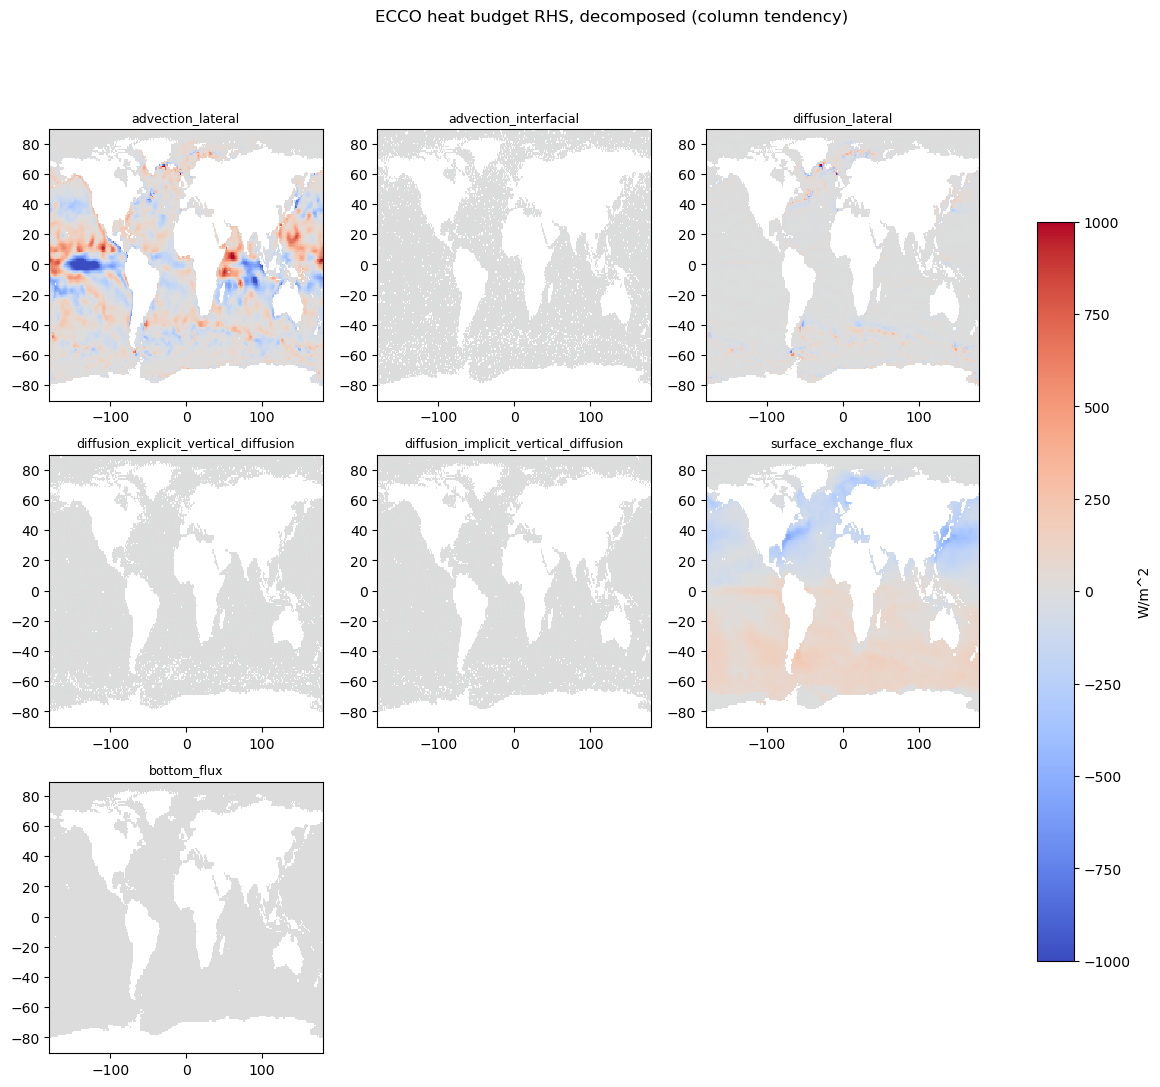

In [7]:
import numpy as np
import matplotlib.pyplot as plt

area = grid._ds["rA"].where(grid._ds["Depth"] > 0.0)

def column_tendency(varname):
    """Column-integrated heat tendency per unit area [W/m^2] at the first time.

    Robust to terms lacking a vertical (`k`) or `time` dimension (e.g. a static
    bottom/geothermal flux).
    """
    da = grid._ds[varname] / area
    if "k" in da.dims:
        da = da.sum("k")
    if "time" in da.dims:
        da = da.isel(time=0)
    return da.where(np.abs(da) > 0.0)

terms = list(heat_rhs_terms.items())
ncol = 3
nrow = int(np.ceil(len(terms) / ncol))
vmax = 1000.0  # W/m^2
fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 4 * nrow), squeeze=False)
for ax in axes.ravel():
    ax.set_visible(False)
cb = None
for (name, varname), ax in zip(terms, axes.ravel()):
    ax.set_visible(True)
    cb = plot_interpolated_ecco(fig, ax, column_tendency(varname), vmin=-vmax, vmax=vmax)
    ax.set_title(name, fontsize=9)
if cb is not None:
    fig.colorbar(cb, ax=axes.ravel().tolist(), orientation="vertical", label="W/m^2", shrink=0.8)
fig.suptitle("ECCO heat budget RHS, decomposed (column tendency)")

### Global-mean time series of each decomposed term

Area-weighted global means summarize the relative magnitude of each contribution over the record.

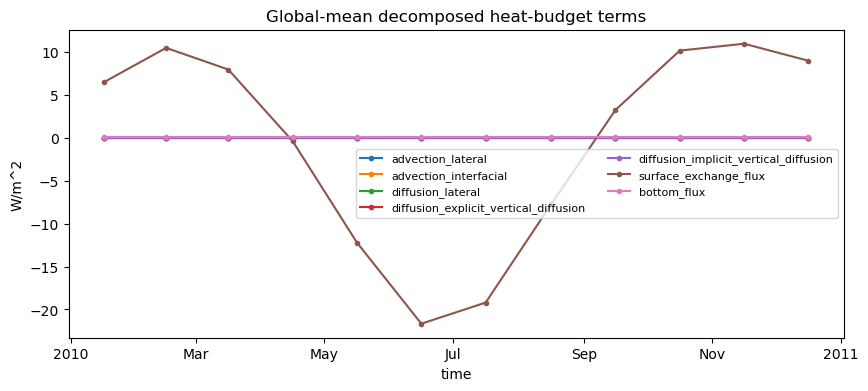

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
for name, varname in heat_rhs_terms.items():
    da = grid._ds[varname] / area
    if "k" in da.dims:
        da = da.sum("k")
    # area-weighted global mean over the horizontal (and tiles)
    global_mean = ((da * area) / area.sum()).sum(["tile", "i", "j"])
    if "time" not in global_mean.dims:
        # static term (e.g. geothermal bottom flux): broadcast to the time axis
        global_mean = global_mean.broadcast_like(grid._ds["time"])
    if not bool(np.isfinite(global_mean).any()):
        continue  # nothing finite to plot for this term
    global_mean.plot(ax=ax, marker="o", ms=3, label=name)
ax.set_ylabel("W/m^2")
ax.set_title("Global-mean decomposed heat-budget terms")
ax.legend(fontsize=8, ncol=2)